### Sleep_health_and_lifestyle_model

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')
print('libraries loaded')

libraries loaded


In [3]:
df=pd.read_csv("C:/Internships/projects/data/Sleep_health_and_lifestyle_dataset.csv", encoding='utf-8-sig')
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [4]:
df.columns = df.columns.str.replace('_', ' ').str.strip().str.replace(' ', '_')
df.columns.tolist()

['Person_ID',
 'Gender',
 'Age',
 'Occupation',
 'Sleep_Duration',
 'Quality_of_Sleep',
 'Physical_Activity_Level',
 'Stress_Level',
 'BMI_Category',
 'Blood_Pressure',
 'Heart_Rate',
 'Daily_Steps',
 'Sleep_Disorder']

In [5]:
df['BMI_Category']=df['BMI_Category'].replace('Normal Weight','Normal')
df['BMI_Category'].unique()

<StringArray>
['Overweight', 'Normal', 'Obese']
Length: 3, dtype: str

In [6]:
df['Sleep_Disorder']=df['Sleep_Disorder'].fillna('None')
df['Sleep_Disorder'].unique()

<StringArray>
['None', 'Sleep Apnea', 'Insomnia']
Length: 3, dtype: str

In [7]:
df.drop(columns=['Person_ID'], inplace=True)

In [8]:
print(df.shape)
df.columns.tolist()

(374, 12)


['Gender',
 'Age',
 'Occupation',
 'Sleep_Duration',
 'Quality_of_Sleep',
 'Physical_Activity_Level',
 'Stress_Level',
 'BMI_Category',
 'Blood_Pressure',
 'Heart_Rate',
 'Daily_Steps',
 'Sleep_Disorder']

In [11]:
#label encoding
le=LabelEncoder()
cat_col=['Gender','Occupation','BMI_Category','Blood_Pressure','Sleep_Disorder']

for col in cat_col:
    df[col]=le.fit_transform(df[col])

print('Encoding done')
df.head()

Encoding done


,Gender,Age,Occupation,Sleep_Duration,Quality_of_Sleep,Physical_Activity_Level,Stress_Level,BMI_Category,Blood_Pressure,Heart_Rate,Daily_Steps,Sleep_Disorder
0,1,27,9,6.1,6,42,6,2,11,77,4200,1
1,1,28,1,6.2,6,60,8,0,9,75,10000,1
2,1,28,1,6.2,6,60,8,0,9,75,10000,1
3,1,28,6,5.9,4,30,8,1,22,85,3000,2
4,1,28,6,5.9,4,30,8,1,22,85,3000,2


In [12]:
print(df.isnull().sum())

Gender                     0
Age                        0
Occupation                 0
Sleep_Duration             0
Quality_of_Sleep           0
Physical_Activity_Level    0
Stress_Level               0
BMI_Category               0
Blood_Pressure             0
Heart_Rate                 0
Daily_Steps                0
Sleep_Disorder             0
dtype: int64


In [17]:
X = df.drop(columns=['Quality_of_Sleep'])
y = df['Quality_of_Sleep']

print('Features: ',X.shape[1])
print('Target: ',y.unique())

Features:  11
Target:  [6 4 7 5 8 9]


In [18]:
#model training
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.2, random_state=42)
print('Training samples: ',X_train.shape[0])
print('Testing samples: ',X_test.shape[0])

Training samples:  299
Testing samples:  75


In [22]:
rf_model=RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [25]:
y_pred=rf_model.predict(X_test)
print('Prediction: ',(y_pred))

Prediction:  [9 6 6 9 6 6 6 8 9 8 6 7 8 6 8 6 6 6 9 8 7 8 6 7 7 8 6 6 6 9 7 8 7 9 6 8 6
 7 8 8 6 6 5 6 8 8 8 7 4 7 9 7 6 8 7 9 7 4 9 6 8 7 6 7 7 6 6 9 8 7 8 6 9 6
 9]


In [27]:
acc=accuracy_score(y_test,y_pred)
print(f"Accuracy: {acc * 100:.2f}%")
print()

Accuracy: 100.00%



In [28]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00        26
           7       1.00      1.00      1.00        16
           8       1.00      1.00      1.00        18
           9       1.00      1.00      1.00        12

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75



In [30]:
# ── Feature Importance ───────────────────────────────────────
importances = pd.Series(
    rf_model2.feature_importances_,
    index=X2.columns
).sort_values(ascending=False)

print(importances)

Stress_Level               0.302683
Age                        0.189902
Heart_Rate                 0.126602
Physical_Activity_Level    0.084674
Blood_Pressure             0.069067
Daily_Steps                0.067123
Occupation                 0.065480
BMI_Category               0.054683
Gender                     0.023155
Sleep_Disorder             0.016631
dtype: float64


In [31]:
print(f"Total rows: {len(df)}")
print(f"Duplicate rows: {df.duplicated().sum()}")

Total rows: 374
Duplicate rows: 242


In [34]:
# ── Remove duplicates ─────────────────────────────────────────
df_clean = df.drop_duplicates()
print("Rows after removing duplicates: ",len(df_clean))

X3 = df_clean.drop(columns=['Quality_of_Sleep', 'Sleep_Duration'])
y3 = df_clean['Quality_of_Sleep']

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3, y3, test_size=0.2, random_state=42
)

rf_model3 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model3.fit(X_train3, y_train3)

y_pred3 = rf_model3.predict(X_test3)
acc3 = accuracy_score(y_test3, y_pred3)
print(f"Accuracy on clean data: {acc3 * 100:.2f}%")
print()
print(classification_report(y_test3, y_pred3))

Rows after removing duplicates:  132
Accuracy on clean data: 96.30%

              precision    recall  f1-score   support

           5       0.67      1.00      0.80         2
           6       1.00      0.88      0.93         8
           7       1.00      1.00      1.00         3
           8       1.00      1.00      1.00        10
           9       1.00      1.00      1.00         4

    accuracy                           0.96        27
   macro avg       0.93      0.97      0.95        27
weighted avg       0.98      0.96      0.97        27



In [36]:
# saving the model
joblib.dump(rf_model3, 'sleep_model.pkl')
joblib.dump(list(X3.columns), 'model_features.pkl')

print("Model saved")
print("Features saved:", list(X3.columns))

Model saved
Features saved: ['Gender', 'Age', 'Occupation', 'Physical_Activity_Level', 'Stress_Level', 'BMI_Category', 'Blood_Pressure', 'Heart_Rate', 'Daily_Steps', 'Sleep_Disorder']


In [37]:
print(importances)

Stress_Level               0.302683
Age                        0.189902
Heart_Rate                 0.126602
Physical_Activity_Level    0.084674
Blood_Pressure             0.069067
Daily_Steps                0.067123
Occupation                 0.065480
BMI_Category               0.054683
Gender                     0.023155
Sleep_Disorder             0.016631
dtype: float64


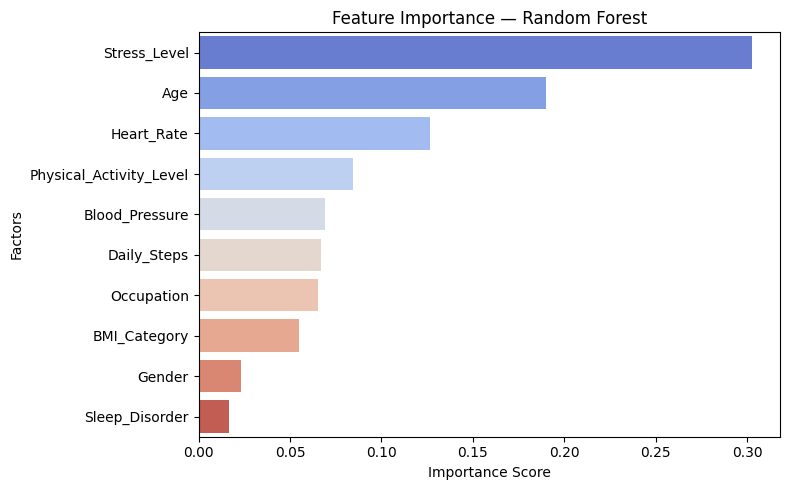

In [39]:
plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, palette='coolwarm')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Factors')
plt.tight_layout()
plt.show()

## Feature Importance Observations

The Random Forest model confirms our EDA findings:

- Stress Level is the single most powerful predictor (0.30) —
  nearly twice as important as the second feature
- Age (0.19) emerges as a strong predictor — 
  not obvious from EDA alone, ML revealed this hidden pattern
- Heart Rate (0.13) reflects physiological stress on the body
- Gender and Sleep Disorder contribute almost nothing to prediction
- Daily Steps (0.07) — low importance, consistent with our 
  EDA finding of 0.02 correlation with sleep quality

### EDA vs ML comparison:
| Factor | EDA finding | ML importance |
|--------|-------------|---------------|
| Stress Level | -0.90 correlation | #1 (0.30) |
| Age | +0.47 correlation | #2 (0.19) |
| Heart Rate | -0.66 correlation | #3 (0.13) |
| Daily Steps | 0.02 correlation | #6 (0.07) |

by both the methods we conclude that: **Stress is the dominant factor.** 